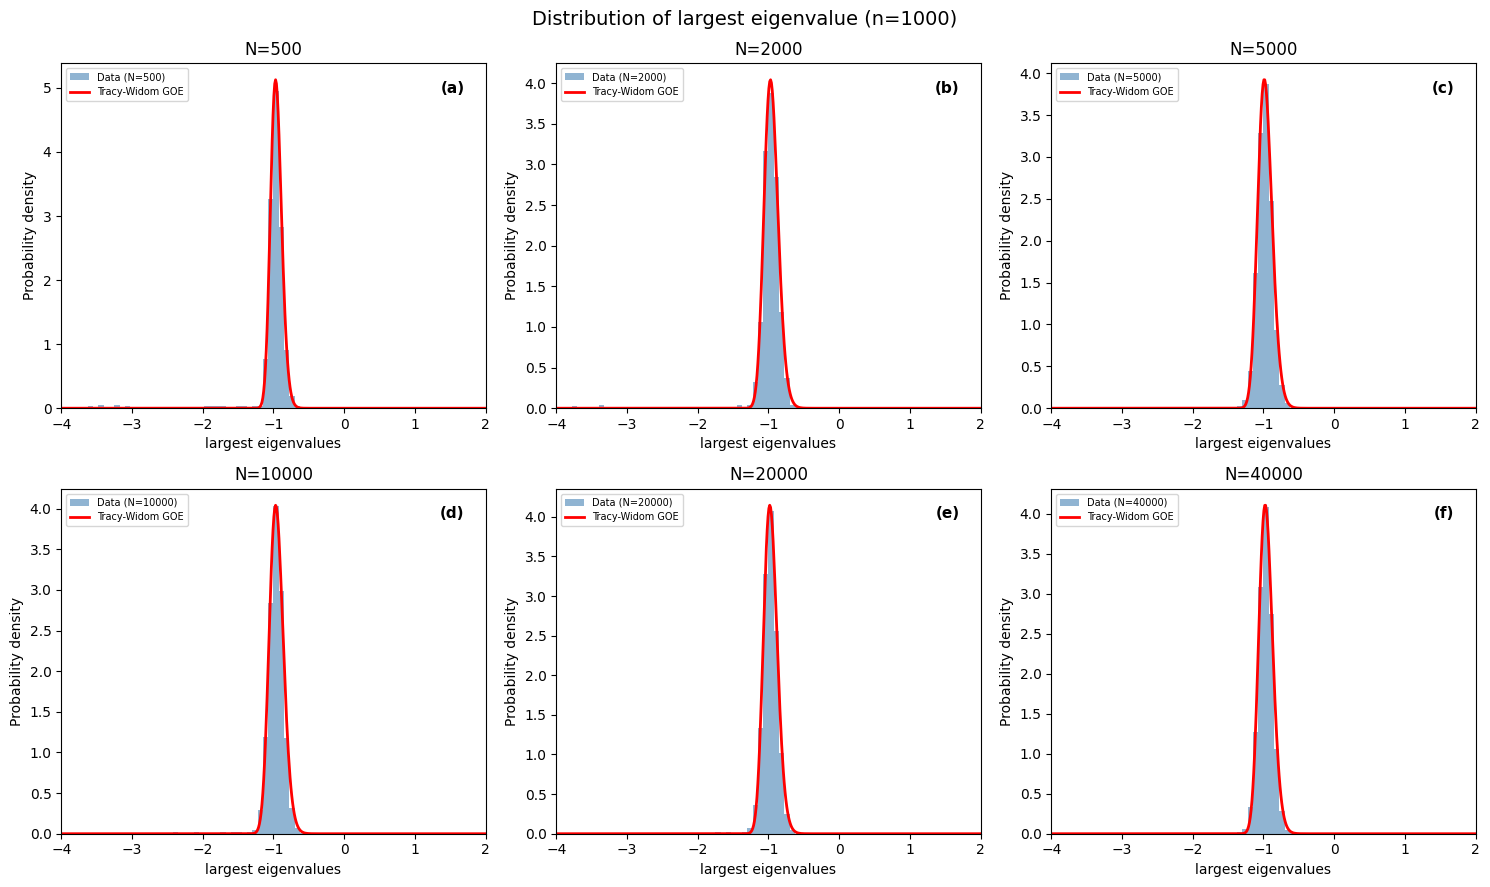

N=   500:  KS_Gaussian=0.462861 (p=1.36e-98)   KS_TW=0.482519 (p=1.19e-107)
N=  2000:  KS_Gaussian=0.437676 (p=0.00e+00)   KS_TW=0.457369 (p=0.00e+00)
N=  5000:  KS_Gaussian=0.440414 (p=0.00e+00)   KS_TW=0.460104 (p=0.00e+00)
N= 10000:  KS_Gaussian=0.439175 (p=0.00e+00)   KS_TW=0.458867 (p=0.00e+00)
N= 20000:  KS_Gaussian=0.440240 (p=0.00e+00)   KS_TW=0.459929 (p=0.00e+00)
N= 40000:  KS_Gaussian=0.440105 (p=0.00e+00)   KS_TW=0.459798 (p=0.00e+00)


In [52]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import curve_fit
from TracyWidom import TracyWidom
import re

tw = TracyWidom(beta=1)

def load_eigs(filename):
    with open(filename, 'r') as f:
        lines = f.readlines()
    values = []
    for line in lines:
        parts = line.split()
        if len(parts) == 2:
            try:
                values.append(float(parts[1]))
            except:
                fixed = re.sub(r'(\d)([-+])(\d{3})', r'\1E\2\3', parts[1])
                try:
                    values.append(float(fixed))
                except:
                    pass
    return np.array(values)

def tw_pdf_wrapper(x, loc, scale):
    return tw.pdf((x - loc) / scale) / scale

ndat_files = {
    500:   ['eigs_ndat500.txt'],
    2000:  ['eigs_ndat2000.txt'],
    5000:  ['eigs_ndat5000.txt'],
    10000: ['eigs_ndat10000.txt'],
    20000: ['eigs_ndat20000.txt'],
    40000: ['eigs_ndat40000.txt'],
}

tw_mean = -1.2065
tw_std  =  1.2680
final   = np.linspace(-4, 2, 500)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, (ndat, files) in enumerate(ndat_files.items()):
    combined = np.concatenate([load_eigs(f) for f in files])
    normal   = combined / np.sqrt(1000)
    z        = (normal - np.mean(normal)) / np.std(normal) * tw_std + tw_mean

    # histogram of all data
    counts, bin_edges = np.histogram(z, bins=5000, density=True)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    # fit TW to main peak bins only
    mask = (bin_centers > tw_mean - 2*tw_std) & (bin_centers < tw_mean + 2*tw_std)
    try:
        popt, _ = curve_fit(tw_pdf_wrapper, bin_centers[mask], counts[mask],
                            p0=[tw_mean, tw_std])
        loc_fit, scale_fit = popt
    except:
        loc_fit, scale_fit = tw_mean, tw_std

    tw_pdf_fitted = tw_pdf_wrapper(final, loc_fit, scale_fit)

    ks_g,  p_g  = stats.kstest(z, 'norm', args=(tw_mean, tw_std))
    ks_tw, p_tw = stats.kstest(z, tw.cdf)

    ax = axes[i]
    ax.hist(z, bins=80, range=(-4, 2), density=True, color='steelblue',
            alpha=0.6, label=f'Data (N={len(z)})')
    ax.plot(final, tw_pdf_fitted, 'r-', linewidth=2, label='Tracy-Widom GOE')
    ax.set_xlim(-4,2)
    ax.set_xlabel('largest eigenvalues')
    ax.set_ylabel('Probability density')
    ax.set_title(f'N={ndat}')
    ax.legend(fontsize=7)
    ax.text(0.95, 0.95, f'({chr(97+i)})', transform=ax.transAxes,
            fontsize=11, fontweight='bold', va='top', ha='right')

plt.suptitle('Distribution of largest eigenvalue (n=1000)', fontsize=14)
plt.tight_layout()
plt.savefig('all_ndat_subplots_n1000.png', dpi=150)
plt.show()




for i, (ndat, files) in enumerate(ndat_files.items()):
    combined = np.concatenate([load_eigs(f) for f in files])
    normal   = combined / np.sqrt(1000)

    mu    = np.mean(normal)
    sigma = np.std(normal)

    # KS vs Gaussian 
    ks_g,  p_g  = stats.kstest(normal, 'norm', args=(mu, sigma))

    # KS vs TW 
    def tw_cdf_scaled(x):
        x_standard = (x - mu) / sigma
        x_tw = x_standard * tw_std + tw_mean
        return tw.cdf(x_tw)

    ks_tw, p_tw = stats.kstest(normal, tw_cdf_scaled)

    print(f"N={ndat:6d}:  KS_Gaussian={ks_g:.6f} (p={p_g:.2e})   KS_TW={ks_tw:.6f} (p={p_tw:.2e})")

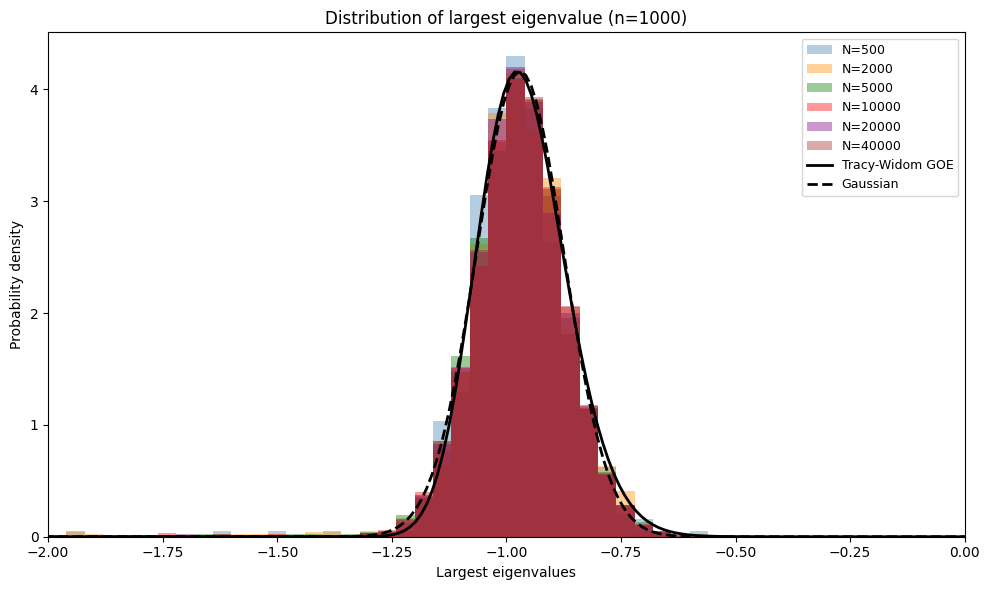

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import norm
from scipy.optimize import curve_fit
from TracyWidom import TracyWidom
import re

tw = TracyWidom(beta=1)

def load_eigs(filename):
    with open(filename, 'r') as f:
        lines = f.readlines()
    values = []
    for line in lines:
        parts = line.split()
        if len(parts) == 2:
            try:
                values.append(float(parts[1]))
            except:
                fixed = re.sub(r'(\d)([-+])(\d{3})', r'\1E\2\3', parts[1])
                try:
                    values.append(float(fixed))
                except:
                    pass
    return np.array(values)

def tw_pdf_wrapper(x, loc, scale):
    return tw.pdf((x - loc) / scale) / scale

def gaussian_wrapper(x, mu, sigma):
    return norm.pdf(x, mu, sigma)

tw_mean = -1.2065
tw_std  =  1.2680

ndat_files = {
    500:   ['eigs_ndat500.txt'],
    2000:  ['eigs_ndat2000.txt'],
    5000:  ['eigs_ndat5000.txt'],
    10000: ['eigs_ndat10000.txt'],
    20000: ['eigs_ndat20000.txt'],
    40000: ['eigs_ndat40000.txt'],
}

colors = ['steelblue', 'darkorange', 'green', 'red', 'purple', 'brown']

# first compute fits using all combined data
all_files = [f for files in ndat_files.values() for f in files]
combined  = np.concatenate([load_eigs(f) for f in all_files])
normal    = combined / np.sqrt(1000)
z_all     = (normal - np.mean(normal)) / np.std(normal) * tw_std + tw_mean

counts, bin_edges = np.histogram(z_all, bins=150, range=(-4, 2), density=True)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
mask = (bin_centers > tw_mean - 2*tw_std) & (bin_centers < tw_mean + 2*tw_std)

try:
    popt_tw, _ = curve_fit(tw_pdf_wrapper, bin_centers[mask], counts[mask],
                           p0=[tw_mean, tw_std])
    loc_fit, scale_fit = popt_tw
except:
    loc_fit, scale_fit = tw_mean, tw_std

try:
    popt_g, _ = curve_fit(gaussian_wrapper, bin_centers[mask], counts[mask],
                          p0=[tw_mean, tw_std])
    mu_fit, sigma_fit = popt_g
except:
    mu_fit, sigma_fit = tw_mean, tw_std

final         = np.linspace(-4, 2, 500)
tw_pdf_fitted = tw_pdf_wrapper(final, loc_fit, scale_fit)
gauss_pdf     = gaussian_wrapper(final, mu_fit, sigma_fit)

fig, ax = plt.subplots(figsize=(10, 6))

for color, (ndat, files) in zip(colors, ndat_files.items()):
    data   = np.concatenate([load_eigs(f) for f in files])
    norm_d = data / np.sqrt(1000)
    z      = (norm_d - np.mean(normal)) / np.std(normal) * tw_std + tw_mean
    ax.hist(z, bins=150, range=(-4, 2), density=True, color=color,
            alpha=0.4, label=f'N={ndat}')

ax.plot(final, tw_pdf_fitted, 'k-',  linewidth=2, label='Tracy-Widom GOE')
ax.plot(final, gauss_pdf,     'k--', linewidth=2, label='Gaussian')
ax.set_xlim(-2, 0)
ax.set_xlabel('Largest eigenvalues')
ax.set_ylabel('Probability density')
ax.set_title(f'Distribution of largest eigenvalue (n=1000)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('combined_n1000_colors.png', dpi=150)
plt.show()

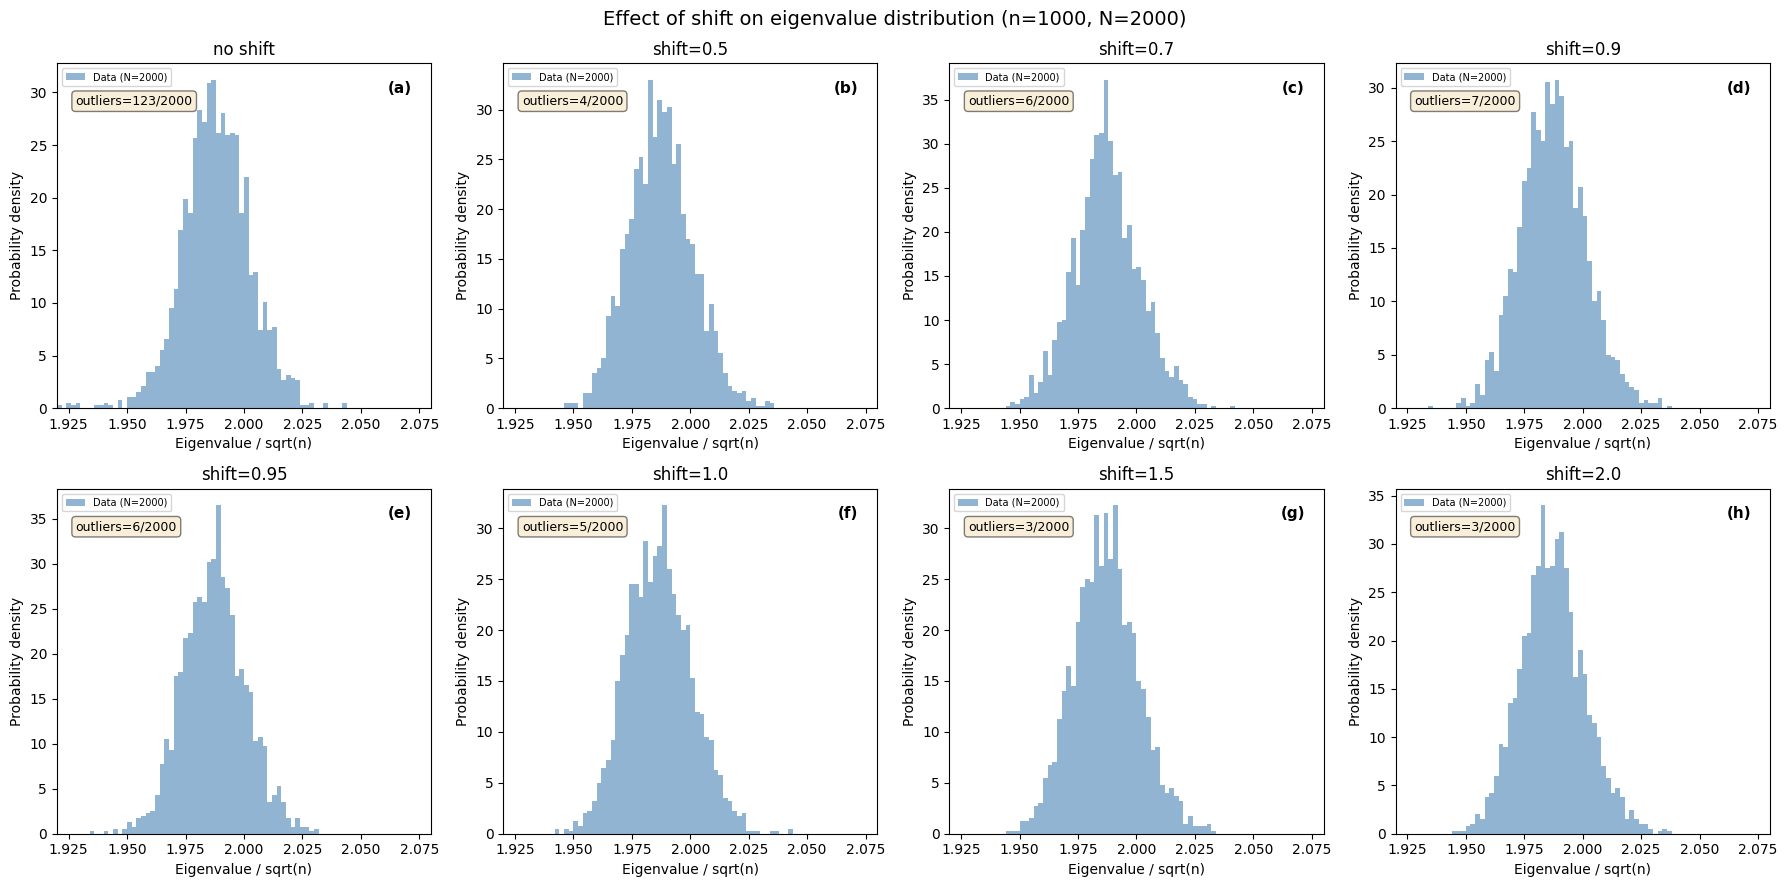

In [55]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import curve_fit
from TracyWidom import TracyWidom
import re

tw = TracyWidom(beta=1)

def load_eigs(filename):
    with open(filename, 'r') as f:
        lines = f.readlines()
    values = []
    for line in lines:
        parts = line.split()
        if len(parts) == 2:
            try:
                values.append(float(parts[1]))
            except:
                fixed = re.sub(r'(\d)([-+])(\d{3})', r'\1E\2\3', parts[1])
                try:
                    values.append(float(fixed))
                except:
                    pass
    return np.array(values)

shift_files = {
    'no shift': 'eigs_ndat2000.txt',
    'shift=0.5':  'eigs_shift_0.5.txt',
    'shift=0.7':  'eigs_shift_0.7.txt',
    'shift=0.9':  'eigs_shift_0.9.txt',
    'shift=0.95': 'eigs_shift_0.95.txt',
    'shift=1.0':  'eigs_shift_1.0.txt',
    'shift=1.5':  'eigs_shift_1.5.txt',
    'shift=2.0':  'eigs_shift_2.0.txt',
}

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

bins = np.linspace(1.92, 2.08, 81)

for i, (label, filename) in enumerate(shift_files.items()):
    data     = load_eigs(filename)
    normal   = data / np.sqrt(1000)
    outliers = (normal < 1.95).sum()

    ax = axes[i]
    ax.hist(normal, bins=bins, density=True, color='steelblue',
            alpha=0.6, label=f'Data (N={len(normal)})')
    ax.set_xlim(1.92, 2.08)
    ax.set_xlabel('Eigenvalue / sqrt(n)')
    ax.set_ylabel('Probability density')
    ax.set_title(label)
    ax.annotate(f'outliers={outliers}/{len(normal)}',
                xy=(0.05, 0.88), xycoords='axes fraction', fontsize=9,
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    ax.legend(fontsize=7)
    ax.text(0.95, 0.95, f'({chr(97+i)})', transform=ax.transAxes,
            fontsize=11, fontweight='bold', va='top', ha='right')

plt.suptitle('Effect of shift on eigenvalue distribution (n=1000, N=2000)', fontsize=14)
plt.tight_layout()
plt.savefig('shift_raw_histogram.png', dpi=150)
plt.show()

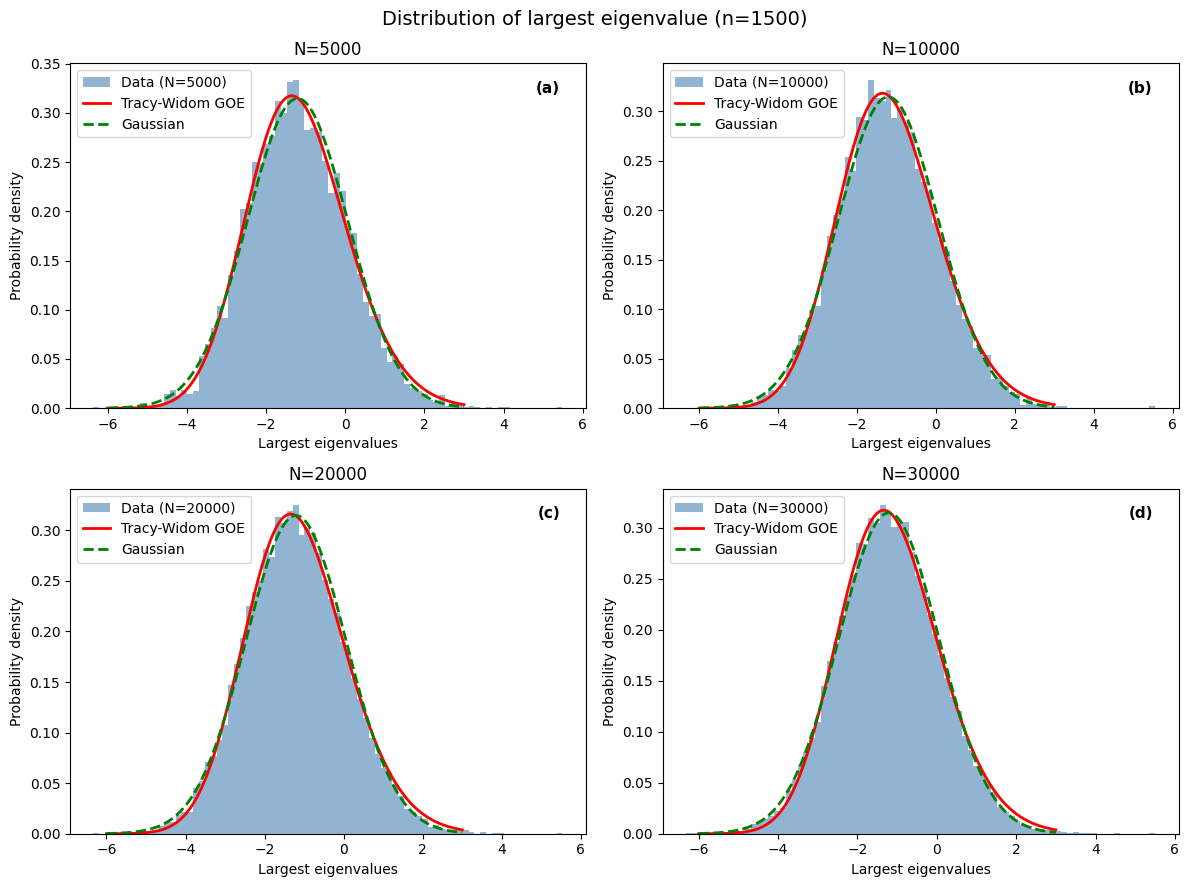

In [65]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import curve_fit
from TracyWidom import TracyWidom
import re

tw = TracyWidom(beta=1)

def load_eigs(filename):
    with open(filename, 'r') as f:
        lines = f.readlines()
    values = []
    for line in lines:
        parts = line.split()
        if len(parts) == 2:
            try:
                values.append(float(parts[1]))
            except:
                fixed = re.sub(r'(\d)([-+])(\d{3})', r'\1E\2\3', parts[1])
                try:
                    values.append(float(fixed))
                except:
                    pass
    return np.array(values)

def tw_pdf_wrapper(x, loc, scale):
    return tw.pdf((x - loc) / scale) / scale

tw_mean = -1.2065
tw_std  =  1.2680

ndat_files = {
    5000:  ['eigs_n1500_ndat5000_shift0.0_run1.txt'],
    10000: ['eigs_n1500_ndat5000_shift0.0_run1.txt',
            'eigs_n1500_ndat5000_shift0.0_run2.txt'],
    20000: ['eigs_n1500_ndat5000_shift0.0_run1.txt',
            'eigs_n1500_ndat5000_shift0.0_run2.txt',
            'eigs_n1500_ndat10000_shift0.0_run1.txt'],
    30000: ['eigs_n1500_ndat5000_shift0.0_run1.txt',
            'eigs_n1500_ndat5000_shift0.0_run2.txt',
            'eigs_n1500_ndat10000_shift0.0_run1.txt',
            'eigs_n1500_ndat10000_shift0.0_run2.txt'],
}

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()

final = np.linspace(-6, 3, 1000)

for i, (ndat, files) in enumerate(ndat_files.items()):
    combined = np.concatenate([load_eigs(f) for f in files])
    normal   = combined / np.sqrt(1500)
    z        = (normal - np.mean(normal)) / np.std(normal) * tw_std + tw_mean

    counts, bin_edges = np.histogram(z, bins=5000, density=True)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    mask = (bin_centers > tw_mean - 2*tw_std) & (bin_centers < tw_mean + 2*tw_std)

    try:
        popt, _ = curve_fit(tw_pdf_wrapper, bin_centers[mask], counts[mask],
                            p0=[tw_mean, tw_std])
        loc_fit, scale_fit = popt
    except:
        loc_fit, scale_fit = tw_mean, tw_std

    tw_pdf_fitted = tw_pdf_wrapper(final, loc_fit, scale_fit)
    gauss_pdf     = stats.norm.pdf(final, tw_mean, tw_std)

    mu    = np.mean(normal)
    sigma = np.std(normal)

    def tw_cdf_scaled(x):
        return tw.cdf((x - mu) / sigma * tw_std + tw_mean)

    ks_g,  p_g  = stats.kstest(normal, 'norm', args=(mu, sigma))
    ks_tw, p_tw = stats.kstest(normal, tw_cdf_scaled)

    ax = axes[i]
    ax.hist(z, bins=80, density=True, color='steelblue',
            alpha=0.6, label=f'Data (N={len(z)})')
    ax.plot(final, tw_pdf_fitted, 'r-',  linewidth=2, label='Tracy-Widom GOE')
    ax.plot(final, gauss_pdf,     'g--', linewidth=2, label='Gaussian')
    # ax.set_xlim(-4, 2)
    ax.set_xlabel('Largest eigenvalues')
    ax.set_ylabel('Probability density')
    ax.set_title(f'N={len(z)}')
    ax.legend()
    ax.text(0.95, 0.95, f'({chr(97+i)})', transform=ax.transAxes,
            fontsize=11, fontweight='bold', va='top', ha='right')

plt.suptitle('Distribution of largest eigenvalue (n=1500)', fontsize=14)
plt.tight_layout()
plt.savefig('n1500_ndat_comparison.png', dpi=150)
plt.show()

In [74]:
import numpy as np
from scipy import stats
from TracyWidom import TracyWidom
import re

tw = TracyWidom(beta=1)

def load_eigs(filename):
    with open(filename, 'r') as f:
        lines = f.readlines()
    values = []
    for line in lines:
        parts = line.split()
        if len(parts) == 2:
            try:
                values.append(float(parts[1]))
            except:
                fixed = re.sub(r'(\d)([-+])(\d{3})', r'\1E\2\3', parts[1])
                try:
                    values.append(float(fixed))
                except:
                    pass
    return np.array(values)

tw_mean = -1.2065
tw_std  =  1.2680

datasets = [
    {'n': 1000, 'ndat': 500,   'files': ['eigs_ndat500.txt']},
    {'n': 1000, 'ndat': 2000,  'files': ['eigs_ndat2000.txt']},
    {'n': 1000, 'ndat': 5000,  'files': ['eigs_ndat5000.txt']},
    {'n': 1000, 'ndat': 10000, 'files': ['eigs_ndat10000.txt']},
    {'n': 1000, 'ndat': 20000, 'files': ['eigs_ndat20000.txt']},
    {'n': 1000, 'ndat': 40000, 'files': ['eigs_ndat40000.txt']},
    {'n': 1500, 'ndat': 5000,  'files': ['eigs_n1500_ndat5000_shift0.0_run1.txt']},
    {'n': 1500, 'ndat': 10000, 'files': ['eigs_n1500_ndat5000_shift0.0_run1.txt',
                                          'eigs_n1500_ndat5000_shift0.0_run2.txt']},
    {'n': 1500, 'ndat': 20000, 'files': ['eigs_n1500_ndat5000_shift0.0_run1.txt',
                                          'eigs_n1500_ndat5000_shift0.0_run2.txt',
                                          'eigs_n1500_ndat10000_shift0.0_run1.txt']},
    {'n': 1500, 'ndat': 30000, 'files': ['eigs_n1500_ndat5000_shift0.0_run1.txt',
                                          'eigs_n1500_ndat5000_shift0.0_run2.txt',
                                          'eigs_n1500_ndat10000_shift0.0_run1.txt',
                                          'eigs_n1500_ndat10000_shift0.0_run2.txt']},
]

print(f"{'n':>6} {'N':>8} {'KS':>12}")
print('-' * 30)

for d in datasets:
    combined = np.concatenate([load_eigs(f) for f in d['files']])
    normal   = combined / np.sqrt(d['n'])
    mu       = np.mean(normal)
    sigma    = np.std(normal)

    def tw_cdf_scaled(x):
        return tw.cdf((x - mu) / sigma * tw_std + tw_mean)

    ks_tw, _ = stats.kstest(normal, tw_cdf_scaled)

    print(f"{d['n']:>6} {len(combined):>8} {ks_tw:>12.6f}")

     n        N           KS
------------------------------
  1000      500     0.482519
  1000     2000     0.457369
  1000     5000     0.460104
  1000    10000     0.458867
  1000    20000     0.459929
  1000    40000     0.459798
  1500     5000     0.009937
  1500    10000     0.008981
  1500    20000     0.011661
  1500    30000     0.012501
